Imports

In [ ]:
import sqlite3 as sql
import pandas as pd
import glob
from pathlib import Path

Create the SQL database 'barrels'

In [ ]:
Path("barrels.db").touch()

In [ ]:
db = "barrels.db"
with sql.connect(db, timeout = 1000) as conn:
    cur = conn.cursor()

Create tables in the database via the provided CSV's from the SMT datasets (gameinfo/lineups).

In [ ]:
for file in glob.glob("data/*.csv"):
    df = pd.read_csv(file)
    print("Creating Table", file[5:-4].replace("-",""))
    df.to_sql(file[5:-4].replace("-",""), conn, if_exists="replace", index=False)

Combining ball events from separate games into one larger dataset

In [ ]:
ball_events_names = []
for file in glob.glob("data/ball-events/*/*/*/*/*.csv"):
    print(file)
    df = pd.read_csv(file)
    print("Creating Table", f'events_{file[28:-16].replace(".5","_5")}')
    ball_events_names.append(f'events_{file[28:-16].replace(".5","_5")}')
    df.to_sql(f'events_{file[28:-16].replace(".5","_5")}', conn, if_exists="replace", index=False)

In [ ]:
##code used from https://stackoverflow.com/questions/68748559/how-to-merge-multiple-tables-of-large-number-of-columns-with-same-schemas-in-pyt
def merge_events(table_names, c):
    if not len(table_names): return
    
    command ="""CREATE TABLE Events AS\n"""

    for i in range(0, len(table_names)):
        command += "SELECT * FROM {}\n".format(table_names[i])
        if (i != len(table_names) - 1): command += "UNION ALL\n"
    
    c.executescript(command)
merge_events(ball_events_names, cur)

Merging ball positions from game specific tables to one large table.

In [ ]:
ball_positions_names = []
for file in glob.glob("data/ball-positions/*/*/*/*/*.csv"):
    print(file)
    df = pd.read_csv(file)
    print("Creating Table", f'ball_positions_{file[31:-19].replace(".5","_5")}')
    ball_positions_names.append(f'ball_positions_{file[31:-19].replace(".5","_5")}')
    df.to_sql(f'ball_positions_{file[31:-19].replace(".5","_5")}', conn, if_exists="replace", index=False)

In [ ]:
def merge_positions(table_names, c):
    if not len(table_names): return
    
    command ="""CREATE TABLE Ball_Pos AS\n"""

    for i in range(0, len(table_names)):
        command += "SELECT * FROM {}\n".format(table_names[i])
        if (i != len(table_names) - 1): command += "UNION ALL\n"
    
    c.executescript(command)
merge_positions(ball_positions_names, cur)

Creating player positions tables, not game specific because these tables are very very large

In [ ]:
player_positions_names = []
for file in glob.glob("data/player-positions/*/*/*/*/*.csv"):
    print(file)
    df = pd.read_csv(file)
    print("Creating Table", f'player_positions_{file[33:-21].replace(".5","_5")}')
    player_positions_names.append(f'player_positions_{file[33:-21].replace(".5","_5")}')
    df.to_sql(f'player_positions_{file[33:-21].replace(".5","_5")}', conn, if_exists="replace", index=False)

Closing and reopening the cursor to free up memory

In [ ]:
cur.close()

Creating ball in play table which merges ball positions with play results and outcomes

In [ ]:
db = "barrels.db"
with sql.connect(db, timeout = 1000) as conn:
    cur = conn.cursor()
join_event_with_pos = """
CREATE TABLE Ball_in_play AS
SELECT b.game_string, b.play_per_game, CAST(b.timestamp AS INTEGER) AS timestamp, b.ball_position_x, b.ball_position_y, b.ball_position_z, e.ball_eventcode
FROM Ball_Pos AS b
LEFT JOIN Events AS e
ON b.game_string = e.game_string
AND b.play_per_game = e.play_per_game
AND b.timestamp = e.timestamp
WHERE EXISTS (
SELECT 1
FROM Events AS e2
WHERE e2.game_string = b.game_string
AND e2.play_per_game = b.play_per_game
AND e2.ball_eventcode = 4
ORDER BY b.game_string, b.play_per_game, b.timestamp
)
"""
drop_table = "DROP TABLE IF EXISTS Ball_in_play"
cur.execute(drop_table)
cur.execute(join_event_with_pos)
conn.commit()
pd.read_sql("SELECT * FROM Ball_in_play", conn).head(25)

This created duplicates so plays with identical timestamps were dropped

In [ ]:
del_dup = """
DELETE FROM Ball_in_play
WHERE rowid NOT IN (
    SELECT MIN(rowid)
    FROM Ball_in_play
    GROUP BY game_string, play_per_game, timestamp
)
"""
cur.execute(del_dup)
conn.commit()
pd.read_sql("SELECT * FROM Ball_in_play", conn).head(25)

Creating a table that is only balls in play and the first 200 ms after contact for easy calculation of exit_velocity. 

In [ ]:
drop_table = "DROP TABLE IF EXISTS ev_calc"
cur.execute(drop_table)
ball_in_play = """
CREATE TABLE ev_calc AS
WITH contact AS (
SELECT b2.game_string, b2.play_per_game, b2.timestamp AS start
FROM ball_in_play as b2
WHERE b2.ball_eventcode = 4
)
SELECT b.game_string, b.play_per_game, b.timestamp, b.ball_position_x, b.ball_position_y, b.ball_position_z
FROM ball_in_play AS b
    JOIN contact AS c
    ON b.game_string = c.game_string
    AND b.play_per_game = c.play_per_game
WHERE b.timestamp >= start AND b.timestamp <= start + 200
ORDER BY b.game_string, b.play_per_game, b.timestamp
"""
cur.execute(ball_in_play)
conn.commit()
pd.read_sql("SELECT * FROM ev_calc", conn).head(25)

Creates table ev_la which calculates the exit velocity via: 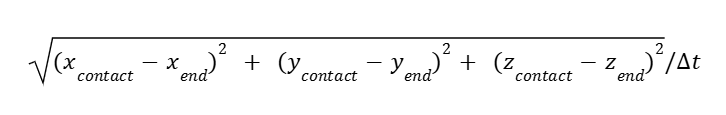


also calculates the launch angle via: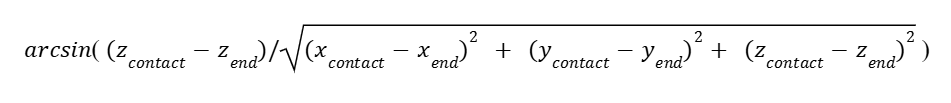
then multiplies by 180/pi to convert from radians to degrees

table also converts milliseconds to seconds by dividing by 1000, feet to inches by multiplying by 12, then inches per second to miles per hour by dividing by 17.6

uses only the ball in play data by for each play selecting the row with minimum timestamp (contact) and the row with maximum timestep to calculate the change in distance for each axis. 

In [ ]:
drop_table = "DROP TABLE IF EXISTS ev_la"
cur.execute(drop_table)
drop_table = "DROP TABLE IF EXISTS delta_phys"
cur.execute(drop_table)
ev = """
CREATE TABLE ev_la AS
WITH delta_ts AS (
SELECT game_string, 
    play_per_game, 
    MIN(timestamp) AS start, 
    MAX(timestamp) AS end_time, 
    (MAX(timestamp) - MIN(timestamp)) / 1000.0 AS delta_t
FROM ev_calc
GROUP BY game_string, play_per_game
),
delta_phys AS (
SELECT t.game_string,
    t.play_per_game,
    start_row.ball_position_x * 12 as start_x,
    start_row.ball_position_y * 12 as start_y, 
    start_row.ball_position_z * 12 as start_z,
    end_row.ball_position_x * 12 as end_x,
    end_row.ball_position_y * 12 as end_y, 
    end_row.ball_position_z * 12 as end_z
FROM delta_ts as t
JOIN ev_calc start_row
    ON start_row.game_string = t.game_string
    AND start_row.play_per_game = t.play_per_game
    AND start_row.timestamp = t.start
JOIN ev_calc end_row
    ON end_row.game_string = t.game_string
    AND end_row.play_per_game = t.play_per_game
    AND end_row.timestamp = t.end_time
)
SELECT
    t2.game_string,
    t2.play_per_game,
    sqrt(pow((p2.end_x - p2.start_x) / t2.delta_t ,2) + pow((p2.end_y - p2.start_y) / t2.delta_t ,2) + pow((p2.end_z - p2.start_z) / t2.delta_t ,2)) / 17.6 AS exit_velocity,
    asin((p2.end_z - p2.start_z) / sqrt(pow((p2.end_x - p2.start_x), 2) + pow((p2.end_y - p2.start_y), 2) + pow((p2.end_z - p2.start_z) ,2))) * 180 / pi() AS launch_angle
FROM delta_ts AS t2
JOIN delta_phys AS p2
ON t2.game_string = p2.game_string
AND t2.play_per_game = p2.play_per_game
ORDER BY t2.game_string, t2.play_per_game
"""
cur.execute(ev)
conn.commit()
pd.read_sql("SELECT * FROM ev_la", conn).head(25)

Some of the resulting rows had null values so I dropped those

In [ ]:
del_null = """
DELETE FROM ev_la
WHERE exit_velocity IS NULL AND launch_angle IS NULL
"""
cur.execute(del_null)
conn.commit()
pd.read_sql("SELECT COUNT(*) FROM ev_la", conn).head(25)

Added a barrel column to the ev_la table which is defined by 98 mph between 26 and 30 degree launch angle. Then for each additional mph, the 26 degree threshold gets smaller by 1.5 degrees, and the 30 degrees threshold increases 1.5 degrees. ie: 100 mph has a la range of 23 - 33 degrees.

In [ ]:
cur.execute("ALTER TABLE ev_la ADD COLUMN barrel")
barrel_classifier = """
UPDATE ev_la SET barrel = 1 
WHERE exit_velocity >= 98.0 
AND launch_angle >= 26 - (exit_velocity - 98) * 1.5 
AND launch_angle <= 30 + (exit_velocity - 98) * 1.5;
"""
cur.execute(barrel_classifier)
conn.commit()
barrel_classifier = """
UPDATE ev_la SET barrel = 0 
WHERE exit_velocity <= 98.0 
OR launch_angle <= 26 - (exit_velocity - 98) * 1.5 
Or launch_angle >= 30 + (exit_velocity - 98) * 1.5;
"""
cur.execute(barrel_classifier)
conn.commit()
pd.read_sql("SELECT * FROM ev_la", conn).head(50)

Proof of outlier exit velocities (MLB record is 122.9 mph)

In [ ]:
pd.read_sql("SELECT exit_velocity FROM ev_la ORDER BY exit_velocity DESC LIMIT 50", conn)

Dropping outliers (122.9 rounded down for the ceiling bc minor leaguers by definition have less polished tools than major leaguers). This has a large amount of exit_velocities over 120 mph which isn't strictly realistic, but it produces the most accurate representation of league average barrel rate we could get without creating crazy outliers. Therefore we call these slightly inflated exit_velocities a limitation of the data. Ideally when implemented at a game they have a way to calculate MLB specific to statcast or whatever data tracking mechanism is league standard.

In [ ]:
del_outliers = """
DELETE FROM ev_la
WHERE exit_velocity > 122
"""
cur.execute(del_outliers)
conn.commit()
pd.read_sql("SELECT * FROM ev_la ORDER BY exit_velocity DESC", conn).head(25)

Total barrels

In [ ]:
pd.read_sql("SELECT COUNT(*) FROM ev_la WHERE barrel = 1", conn).head(50)

Total balls in play

In [ ]:
pd.read_sql("SELECT COUNT(*) FROM ev_la", conn).head(50)

Average barrel rate across the dataset

In [ ]:
703/7356

Converting the barrels table to a csv

In [ ]:
import csv

with sql.connect("barrels.db") as connection:
    csvWriter = csv.writer(open("barrels.csv", "w", newline=""))
    c = connection.cursor()
    c.execute("SELECT * FROM ev_la")
    csvWriter.writerow(['game_string','play_per_game','exit_velocity','launch_angle','barrel'])
    rows = c.fetchall()
    csvWriter.writerows(rows)

In [ ]:
conn.close()

In [ ]:
db = "barrels.db"
with sql.connect(db, timeout = 1000) as conn:
    cur = conn.cursor()

Creating tables based on the pitch classification .py files done by other team members

In [ ]:
for file in glob.glob("./*.csv"):
    df = pd.read_csv(file)
    print("Creating Table", file[2:-4].replace("-",""))
    df.to_sql(file[2:-4].replace("-",""), conn, if_exists="replace", index=False)

Creating table which combines first pitch data with the barrel classification

In [ ]:
db = "barrels.db"
with sql.connect(db, timeout = 1000) as conn:
    cur = conn.cursor()
join_fp_bar = """
CREATE TABLE First_pitch_barrel
AS
SELECT f.game_string, f.play_per_game, f.pitch_release_time, f.pitch_end_time, f.result_in_play, f.first_pitch, f.pitcher, f.batter, b.barrel, b.exit_velocity, b.launch_angle
FROM first_pitches AS f
LEFT JOIN ev_la AS b
ON f.game_string = b.game_string 
AND f.play_per_game = b.play_per_game
ORDER BY f.game_string, f.play_per_game
"""
drop_table = "DROP TABLE IF EXISTS First_pitch_barrel"
cur.execute(drop_table)
cur.execute(join_fp_bar)
conn.commit()
pd.read_sql("SELECT * FROM First_pitch_barrel", conn).head(5)

Dropping null values if exist again

In [ ]:
del_null = """
DELETE FROM First_pitch_barrel
WHERE pitcher IS NULL AND batter IS NULL
"""
cur.execute(del_null)
conn.commit()
pd.read_sql("SELECT * FROM First_pitch_barrel", conn).head(25)

Deleting duplicate data if exists again

In [ ]:
del_dup = """
DELETE FROM First_pitch_barrel
WHERE rowid NOT IN (
    SELECT MIN(rowid)
    FROM First_pitch_barrel
    GROUP BY game_string, play_per_game, pitch_release_time
)
"""
cur.execute(del_dup)
conn.commit()
pd.read_sql("SELECT * FROM First_pitch_barrel", conn).head(25)

Total barrels on first pitch

In [ ]:
pd.read_sql("SELECT COUNT(*) FROM First_pitch_barrel WHERE barrel = 1.0", conn).head(50)

Total first pitches

In [ ]:
pd.read_sql("SELECT COUNT(*) FROM First_pitch_barrel", conn).head(50)

Average rate of barrel on first pitches

In [ ]:
136/18880

Creatinig a leaderboard of specific players barrels on first pitches

In [ ]:
drop_table = "DROP TABLE IF EXISTS leaderboard"
cur.execute(drop_table)
leaderboard = """
CREATE TABLE leaderboard
AS
SELECT batter, SUM(barrel) AS barrels
FROM First_pitch_barrel
GROUP BY batter
"""
cur.execute(leaderboard)
conn.commit()

Dropping players without first pitch barrels

In [ ]:
del_0 = """
DELETE FROM leaderboard
WHERE barrels < 0.5 OR barrels is NULL
"""
cur.execute(del_0)
conn.commit()

In [ ]:
pd.read_sql("SELECT * FROM leaderboard ORDER BY barrels DESC", conn).head(25)

Converting the first pitch barrel table to csv

In [ ]:
import csv

with sql.connect("barrels.db") as connection:
    csvWriter = csv.writer(open("first_pitch_barrel.csv", "w", newline=""))
    c = connection.cursor()
    c.execute("SELECT * FROM First_pitch_barrel")
    csvWriter.writerow(['game_string','play_per_game','pitch_release_time','pitch_end_time','result_in_play','first_pitch','pitcher','batter','exit_velocity','launch_angle'])
    rows = c.fetchall()
    csvWriter.writerows(rows)

Converting the leaderboard to a csv

In [ ]:
import csv

with sql.connect("barrels.db") as connection:
    csvWriter = csv.writer(open("leaderboard.csv", "w", newline=""))
    c = connection.cursor()
    c.execute("SELECT * FROM leaderboard")
    csvWriter.writerow(['batter','barrels'])
    rows = c.fetchall()
    csvWriter.writerows(rows)

Creating a table that combines the first pitch barrels with specific pitch types and whether or not the result was a home run. Ie: calculating total number of First Pitch Fastball Fiestas

In [ ]:
db = "barrels.db"
with sql.connect(db, timeout = 1000) as conn:
    cur = conn.cursor()
join_fp_bar = """
CREATE TABLE First_pitch_fastball_fiesta
AS
SELECT p.game_string, p.play_per_game, p.first_pitch, p.batter, p.result_HR, p.pitch_type, b.barrel
FROM pitches_classified AS p
LEFT JOIN barrels AS b
ON p.game_string = b.game_string 
AND p.play_per_game = b.play_per_game
ORDER BY p.game_string, p.play_per_game
"""
drop_table = "DROP TABLE IF EXISTS First_pitch_fastball_fiesta"
cur.execute(drop_table)
cur.execute(join_fp_bar)
conn.commit()
pd.read_sql("SELECT * FROM First_pitch_fastball_fiesta", conn).head(25)

Creating a leaderboard of fiestas

In [ ]:
pd.read_sql("SELECT COUNT(result_HR) AS FPFF, batter FROM First_pitch_fastball_fiesta WHERE barrel = 1.0 AND pitch_type = 'Fastball' AND first_pitch = 1 AND result_HR = 1 GROUP BY batter ORDER BY FPFF DESC", conn).head(50)

Converting the fiesta table to a csv

In [ ]:
with sql.connect("barrels.db") as connection:
    csvWriter = csv.writer(open("First_pitch_fastball_fiesta.csv", "w", newline=""))
    c = connection.cursor()
    c.execute("SELECT * FROM First_pitch_fastball_fiesta")
    csvWriter.writerow(['game_string','play_per_game','first_pitch','batter','result_HR','pitch_type','barrel'])
    rows = c.fetchall()
    csvWriter.writerows(rows)

Total first pitch fastballs hit for homeruns ie: total fiestas

In [ ]:
pd.read_sql("SELECT COUNT(result_HR) AS FPFF FROM First_pitch_fastball_fiesta WHERE barrel = 1.0 AND pitch_type = 'Fastball' AND first_pitch = 1 AND result_HR = 1", conn).head(50)

In [ ]:
conn.close()

In [ ]:
db = "barrels.db"
with sql.connect(db, timeout = 1000) as conn:
    cur = conn.cursor()
join_fp_bar = """
CREATE TABLE leaderboard2
AS
SELECT p.batter, p.result_HR, p.pitch_type, b.barrel AS barrels, pitch_type = 'Fastball' AND b.barrel = 1 AS "barrels(fastball)"
FROM pitches_classified AS p
LEFT JOIN barrels AS b
ON p.game_string = b.game_string 
AND p.play_per_game = b.play_per_game
WHERE p.first_pitch = 1
ORDER BY b.barrel DESC
"""
drop_table = "DROP TABLE IF EXISTS leaderboard2"
cur.execute(drop_table)
cur.execute(join_fp_bar)
conn.commit()
pd.read_sql("SELECT * FROM leaderboard2", conn).head(50)

In [ ]:
pd.read_sql("SELECT * FROM leaderboard2", conn).head(25)

In [ ]:
with sql.connect("barrels.db") as connection:
    csvWriter = csv.writer(open("leaderboard2.csv", "w", newline=""))
    c = connection.cursor()
    c.execute("SELECT * FROM leaderboard2")
    csvWriter.writerow(['batter','result_HR','pitch_type','barrels','barrels(fastball)'])
    rows = c.fetchall()
    csvWriter.writerows(rows)

In [ ]:
db = "barrels.db"
with sql.connect(db, timeout = 1000) as conn:
    cur = conn.cursor()
join_fp_bar = """
CREATE TABLE barrels_ranking
AS
SELECT p.batter AS player_id, p.result_HR, SUM(b.barrel) AS barrels, SUM(pitch_type = 'Fastball' AND b.barrel = 1) AS "barrels_fastballs", SUM(pitch_type = 'Fastball' AND result_HR = 1) AS fiestas
FROM pitches_classified AS p
LEFT JOIN barrels AS b
ON p.game_string = b.game_string 
AND p.play_per_game = b.play_per_game
WHERE p.first_pitch = 1
GROUP BY player_id
ORDER BY barrels DESC
"""
drop_table = "DROP TABLE IF EXISTS barrels_ranking"
cur.execute(drop_table)
cur.execute(join_fp_bar)
conn.commit()
pd.read_sql("SELECT * FROM barrels_ranking", conn).head(50)